In [316]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from sklearn.preprocessing import StandardScaler

In [317]:
df = pd.read_csv("W:/Data-Science-Main/Data/housing.csv")

In [318]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [319]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [320]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [321]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [322]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].mean())

In [323]:
df.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [324]:
df = df[df['median_house_value'] < 500000]

In [325]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [326]:
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

In [327]:
X = df.drop('median_house_value', axis=1)
Y = df['median_house_value']

In [328]:
xTrain, xTest, yTrain, yTest = train_test_split(X, Y, test_size=0.2, random_state=42)

In [329]:
model = LinearRegression()
model.fit(xTrain, yTrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [330]:
predictions = model.predict(xTest)

In [331]:
mse = mean_squared_error(yTest, predictions)
rmse = root_mean_squared_error(yTest, predictions)
r2 = r2_score(yTest, predictions)

In [332]:
print(f"Mean Squared Error (RMSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared Score: {r2}")

Mean Squared Error (RMSE): 3711056055.6930556
Root Mean Squared Error (RMSE): 60918.43773188094
R-squared Score: 0.612918639377099


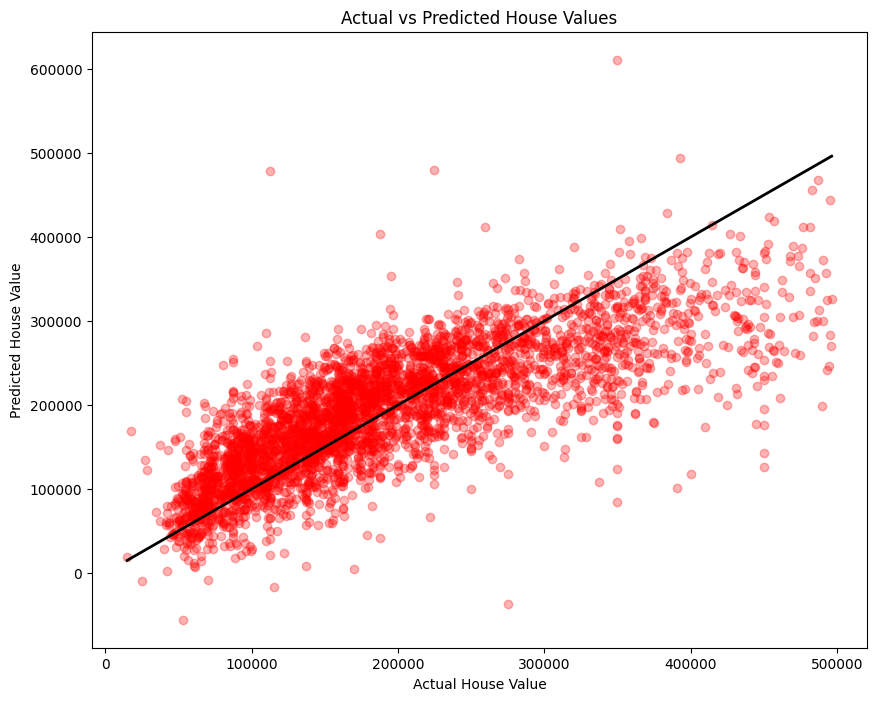

In [333]:
plt.figure(figsize=(10, 8))
plt.scatter(yTest, predictions, alpha=0.3, color='red')

plt.plot([yTest.min(), yTest.max()], [yTest.min(), yTest.max()], 'black', lw=2)

plt.xlabel('Actual House Value')
plt.ylabel('Predicted House Value')
plt.title('Actual vs Predicted House Values')
plt.show()

In [334]:
df2 = pd.read_csv("W:/Data-Science-Main/Data/housing.csv")

In [335]:
df2

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [336]:
df2['total_bedrooms'] = df2['total_bedrooms'].fillna(df2['total_bedrooms'].mean())

In [337]:
df2.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [338]:
df2 = df2[df2['median_house_value'] < 500000]

In [339]:
df2['median_house_value'].sort_values(ascending=False).head(20)

10652    499100.0
1639     499000.0
18083    498800.0
4237     498700.0
6915     498600.0
5753     498400.0
4114     497600.0
5889     497400.0
14376    496400.0
18054    496400.0
17100    496000.0
17048    495900.0
9423     495800.0
4218     495600.0
4106     495600.0
8627     495500.0
11509    495500.0
4068     495500.0
10402    495400.0
5325     494700.0
Name: median_house_value, dtype: float64

In [340]:
df2 = pd.get_dummies(df2, columns=['ocean_proximity'], drop_first=True)

In [341]:
df2

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,True,False,False,False
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,True,False,False,False
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,True,False,False,False
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,True,False,False,False


In [342]:
features = df2.drop('median_house_value', axis=1)
target = df2['median_house_value']

In [343]:
x2Train, x2Test, y2Train, y2Test = train_test_split(features, target, test_size=0.2, random_state=42)

In [344]:
scaler = StandardScaler()

In [345]:
x2TrainScaled = scaler.fit_transform(x2Train)
x2TestScaled = scaler.transform(x2Test)

In [346]:
model = LinearRegression()

In [347]:
model.fit(x2TrainScaled,y2Train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [348]:
prediction2 = model.predict(x2TestScaled)

In [349]:
mse2 = mean_squared_error(y2Test, prediction2)
rmse2 = root_mean_squared_error(y2Test, prediction2)
r2Scaled = r2_score(y2Test, prediction2)
r2Val = r2Scaled*100

In [350]:
print(f"MSE Scaled: {mse2}")
print(f"RMSE Scaled: {rmse2}")
print(f"R2 Scaled: {r2Val:,.4f} %")

MSE Scaled: 3711056055.6930714
RMSE Scaled: 60918.43773188107
R2 Scaled: 61.2919 %


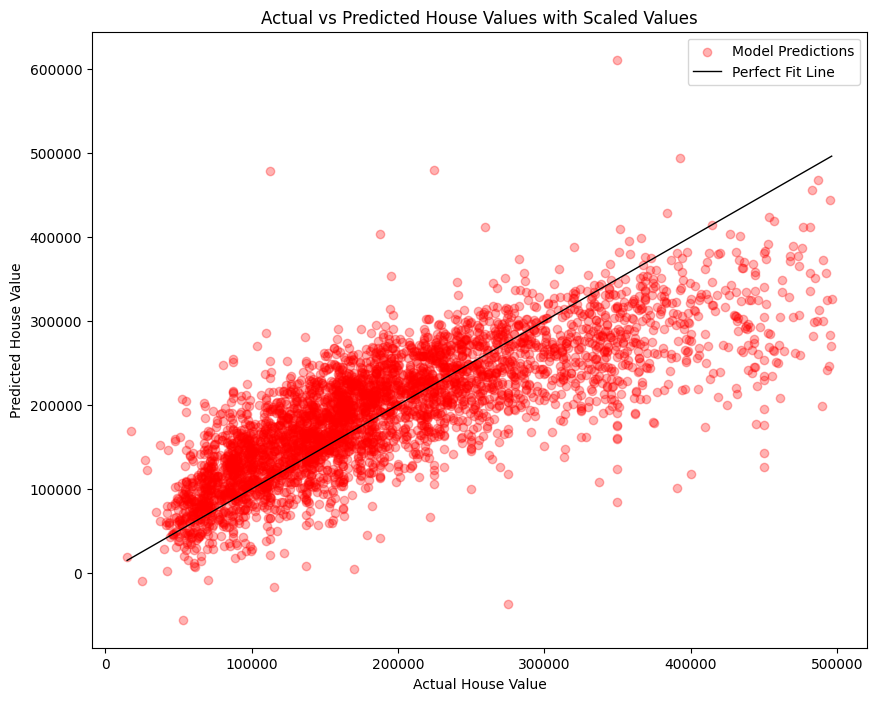

In [351]:
plt.figure(figsize=(10, 8))
plt.scatter(y2Test, prediction2, alpha=0.3, color='red',label='Model Predictions')

plt.plot([y2Test.min(), y2Test.max()], [y2Test.min(), y2Test.max()], 'black', lw=1, label='Perfect Fit Line')

plt.xlabel('Actual House Value')
plt.ylabel('Predicted House Value')
plt.legend()
plt.title('Actual vs Predicted House Values with Scaled Values')
plt.show()

In [352]:
df3 = pd.read_csv("W:/Data-Science-Main/Data/housing.csv")

In [353]:
df3.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [354]:
df3['total_bedrooms'] = df3['total_bedrooms'].fillna(df3['total_bedrooms'].mean())

In [355]:
df3.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [356]:
df3 = pd.get_dummies(df3, columns=['ocean_proximity'], drop_first=True)

In [357]:
df3['rooms_per_household'] = df3['total_rooms'] / df3['households']
df3['bedrooms_per_room'] = df3['total_bedrooms'] / df3['total_rooms']
df3['population_per_household'] = df3['population'] / df3['households']

In [358]:
df3 = df3[df3['population_per_household'] < 10]

In [359]:
df3.shape

(20603, 16)

In [360]:
df3.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
count,20603.000000,20603.000000,20603.000000,20603.000000,20603.000000,20603.000000,20603.000000,20603.000000,20603.000000,20603.000000,20603.000000,20603.000000
mean,-119.569189,35.631012,28.637092,2639.426783,538.603029,1423.339368,500.224822,3.870548,206901.007475,5.428533,0.214417,2.918517
std,2.003460,2.135875,12.580805,2181.680803,419.247219,1128.241516,382.299135,1.897012,115365.426790,2.471073,0.069531,0.765234
min,-124.350000,32.540000,1.000000,2.000000,2.000000,3.000000,2.000000,0.499900,14999.000000,0.846154,0.045937,0.692308
25%,-121.800000,33.930000,18.000000,1451.000000,298.000000,787.000000,280.000000,2.564350,119600.000000,4.440829,0.175360,2.428935
50%,-118.490000,34.260000,29.000000,2128.000000,438.000000,1166.000000,410.000000,3.534900,179800.000000,5.229682,0.203280,2.817259
75%,-118.010000,37.710000,37.000000,3149.500000,644.000000,1724.000000,605.500000,4.743850,264900.000000,6.052108,0.240224,3.279038
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,141.909091,3.492666,9.954545


In [361]:
x3 = df3.drop('median_house_value', axis=1)
y3 = df3['median_house_value']

In [362]:
x3Train, x3Test, y3Train, y3Test = train_test_split(x3, y3, test_size=0.2, random_state=42)

In [363]:
scaler = StandardScaler()

In [364]:
x3TrainScaled = scaler.fit_transform(x3Train)
x3TestScaled = scaler.transform(x3Test)


In [365]:
model = LinearRegression()

In [366]:
model.fit(x3TrainScaled, y3Train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [367]:
prediction3 = model.predict(x3TestScaled)

In [368]:
mse3 = mean_squared_error(y3Test, prediction3)
rmse3 = root_mean_squared_error(y3Test, prediction3)
r3Scaled = r2_score(y3Test, prediction3)
r3Val = r3Scaled*100

In [369]:
print(f"MSE Scaled Featured: {mse3}")
print(f"RMSE Scaled Featured: {rmse3}")
print(f"R2 Scaled Featured: {r3Val:,.4f} %")

MSE Scaled Featured: 4419718085.828758
RMSE Scaled Featured: 66480.96032571098
R2 Scaled Featured: 66.7117 %


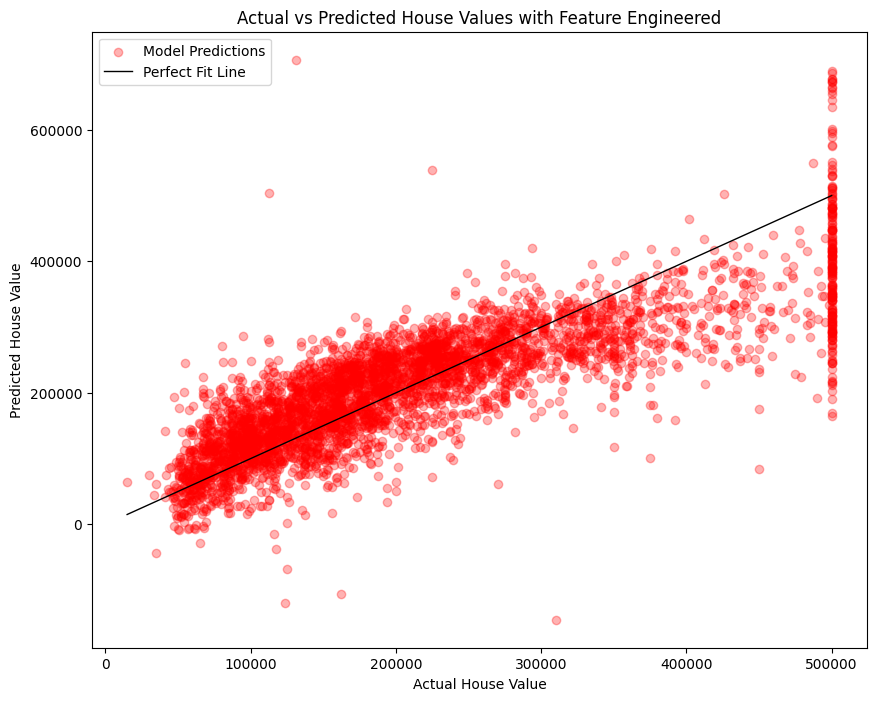

In [370]:
plt.figure(figsize=(10, 8))
plt.scatter(y3Test, prediction3, alpha=0.3, color='red',label='Model Predictions')

plt.plot([y3Test.min(), y3Test.max()], [y3Test.min(), y3Test.max()], 'black', lw=1, label='Perfect Fit Line')

plt.xlabel('Actual House Value')
plt.ylabel('Predicted House Value')
plt.legend()
plt.title('Actual vs Predicted House Values with Feature Engineered')
plt.show()